# Trabalho 1 — Processos Estocásticos — Resolução

Caracterização de um sistema **LIT discreto** excitado por processos estocásticos.
A resolução está dividida em:

- **A.** Conjunto `dados_treino_branco.csv` (entrada aproximadamente branca)
- **B.** Conjunto `dados_treino_colorido.csv` (entrada colorida)
- **C.** Conjunto `dados_teste_anomalia.csv` (detecção de anomalia)

Este notebook foca em **produzir resultados**; a redação do relatório fica para depois.

## Configuração e funções auxiliares

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

PROJECT_ROOT = Path.cwd()
if (PROJECT_ROOT / "dados_treino_branco.csv").exists():
    DATA_DIR = PROJECT_ROOT
elif (PROJECT_ROOT.parent / "dados_treino_branco.csv").exists():
    DATA_DIR = PROJECT_ROOT.parent
else:
    DATA_DIR = PROJECT_ROOT / "data"

# Frequência de amostragem: não informada -> assumimos fs = 1 Hz (frequência normalizada)
FS = 1.0

print("DATA_DIR:", DATA_DIR)

DATA_DIR: C:\Users\DELL\Documents\GitHub\stochastic_processes


In [2]:
def load_dataset(filename):
    """Carrega um CSV com colunas n, u, y."""
    df = pd.read_csv(DATA_DIR / filename)
    return df["n"].to_numpy(), df["u"].to_numpy(), df["y"].to_numpy()


def biased_autocorr(x, max_lag=None):
    """Autocorrelação (estimador enviesado) para lags 0..max_lag do sinal centrado."""
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    full = np.correlate(x, x, mode="full") / n
    mid = n - 1
    if max_lag is None:
        max_lag = n - 1
    return full[mid : mid + max_lag + 1]


def biased_crosscorr(x, y, max_lag):
    """Correlação cruzada R_xy[k] = E{x[n+k] y[n]} (centrada), lags -max_lag..max_lag."""
    x = np.asarray(x, dtype=float) - np.mean(x)
    y = np.asarray(y, dtype=float) - np.mean(y)
    n = len(x)
    full = np.correlate(x, y, mode="full") / n
    mid = n - 1
    lags = np.arange(-max_lag, max_lag + 1)
    return lags, full[mid - max_lag : mid + max_lag + 1]

---
# A. Conjunto `dados_treino_branco.csv`

Amostras: 5000


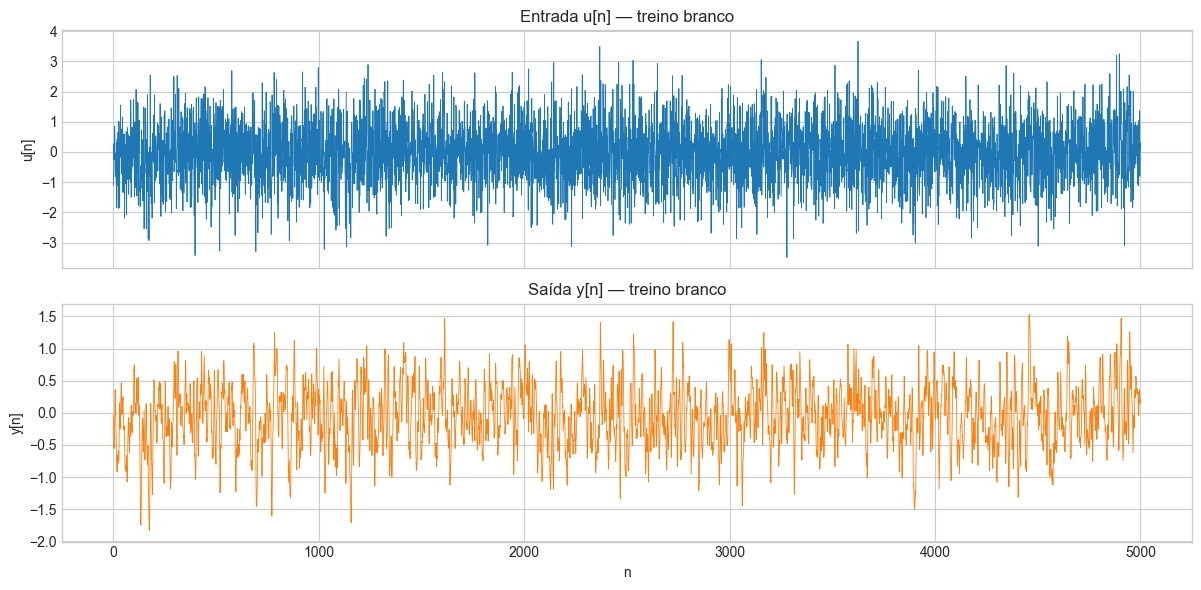

In [3]:
n_a, u_a, y_a = load_dataset("dados_treino_branco.csv")
print(f"Amostras: {len(n_a)}")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(n_a, u_a, linewidth=0.6)
axes[0].set_ylabel("u[n]")
axes[0].set_title("Entrada u[n] — treino branco")
axes[1].plot(n_a, y_a, linewidth=0.6, color="C1")
axes[1].set_ylabel("y[n]")
axes[1].set_xlabel("n")
axes[1].set_title("Saída y[n] — treino branco")
plt.tight_layout()
plt.show()

## A.1 — Média, variância e autocorrelação de u[n] e y[n]

In [4]:
stats = pd.DataFrame(
    {
        "sinal": ["u[n]", "y[n]"],
        "média": [u_a.mean(), y_a.mean()],
        "variância": [u_a.var(), y_a.var()],
        "desvio padrão": [u_a.std(), y_a.std()],
        "mínimo": [u_a.min(), y_a.min()],
        "máximo": [u_a.max(), y_a.max()],
    }
)
stats

,sinal,média,variância,desvio padrão,mínimo,máximo
0,u[n],-0.032065,0.988808,0.994388,-3.496153,3.669266
1,y[n],-0.043447,0.231322,0.480960,-1.834390,1.528619


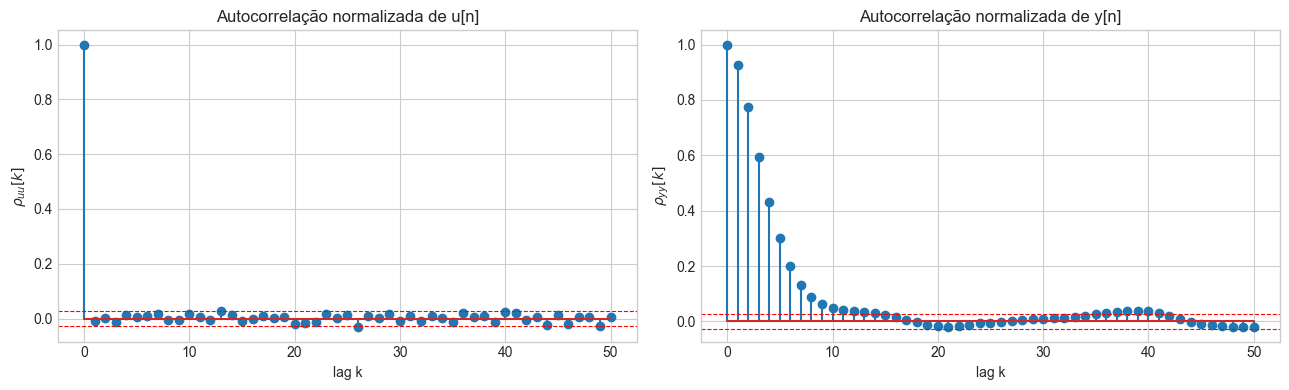

Banda de confiança ~95%: +/- 0.0277
u[n]: fração de |rho| (lags>=1) acima da banda: 0.040
y[n]: fração de |rho| (lags>=1) acima da banda: 0.400


In [5]:
MAX_LAG = 50
lags_pos = np.arange(MAX_LAG + 1)
r_uu = biased_autocorr(u_a, MAX_LAG)
r_yy = biased_autocorr(y_a, MAX_LAG)

# Normalizadas (coeficiente de autocorrelação) para visualização
rho_uu = r_uu / r_uu[0]
rho_yy = r_yy / r_yy[0]

# Banda de confiança ~95% para ruído branco
conf = 1.96 / np.sqrt(len(u_a))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].stem(lags_pos, rho_uu)
axes[0].axhline(conf, color="r", ls="--", lw=0.8)
axes[0].axhline(-conf, color="r", ls="--", lw=0.8)
axes[0].set_title("Autocorrelação normalizada de u[n]")
axes[0].set_xlabel("lag k")
axes[0].set_ylabel(r"$\rho_{uu}[k]$")

axes[1].stem(lags_pos, rho_yy)
axes[1].axhline(conf, color="r", ls="--", lw=0.8)
axes[1].axhline(-conf, color="r", ls="--", lw=0.8)
axes[1].set_title("Autocorrelação normalizada de y[n]")
axes[1].set_xlabel("lag k")
axes[1].set_ylabel(r"$\rho_{yy}[k]$")
plt.tight_layout()
plt.show()

print(f"Banda de confiança ~95%: +/- {conf:.4f}")
print(f"u[n]: fração de |rho| (lags>=1) acima da banda: "
      f"{np.mean(np.abs(rho_uu[1:]) > conf):.3f}")
print(f"y[n]: fração de |rho| (lags>=1) acima da banda: "
      f"{np.mean(np.abs(rho_yy[1:]) > conf):.3f}")

**Leitura esperada:** se `u[n]` é aproximadamente branco, `rho_uu[k] ≈ 0` para `k != 0` (dentro da banda). Já `y[n]` deve apresentar autocorrelação com memória (decaimento), pois é a saída filtrada pelo sistema LIT.

## A.2 — Correlação cruzada entre u[n] e y[n]

Para entrada branca, $R_{uy}[k] = \sigma_u^2\, h[k]$, ou seja, a correlação cruzada revela (a menos de escala) a **resposta ao impulso** do sistema.

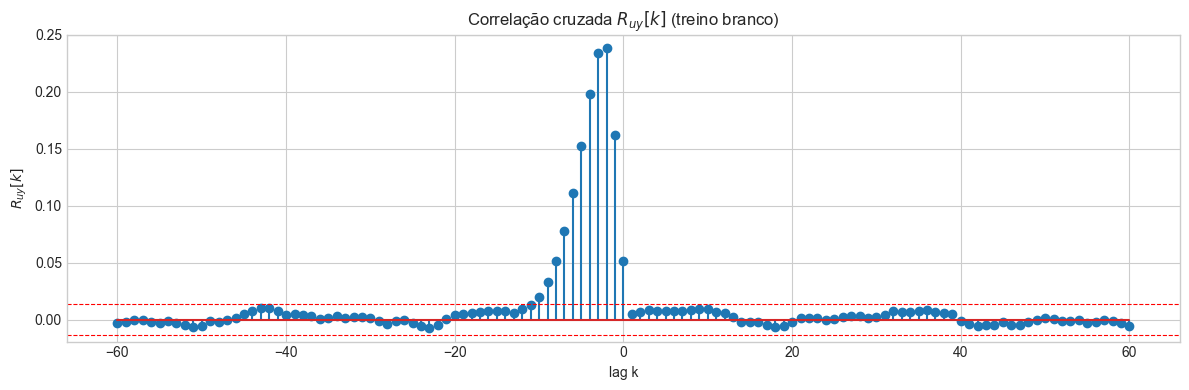

Pico de |R_uy| no lag k = -2
Lags negativos ~0 indicam sistema causal (saída não antecede a entrada).


In [6]:
CC_LAG = 60
lags_cc, r_uy = biased_crosscorr(u_a, y_a, CC_LAG)

plt.figure(figsize=(12, 4))
plt.stem(lags_cc, r_uy)
plt.axhline(conf * u_a.std() * y_a.std(), color="r", ls="--", lw=0.8)
plt.axhline(-conf * u_a.std() * y_a.std(), color="r", ls="--", lw=0.8)
plt.title(r"Correlação cruzada $R_{uy}[k]$ (treino branco)")
plt.xlabel("lag k")
plt.ylabel(r"$R_{uy}[k]$")
plt.tight_layout()
plt.show()

k_peak = lags_cc[np.argmax(np.abs(r_uy))]
print(f"Pico de |R_uy| no lag k = {k_peak}")
print("Lags negativos ~0 indicam sistema causal (saída não antecede a entrada).")

## A.3 — PSD de u[n] e y[n] (método de Welch)

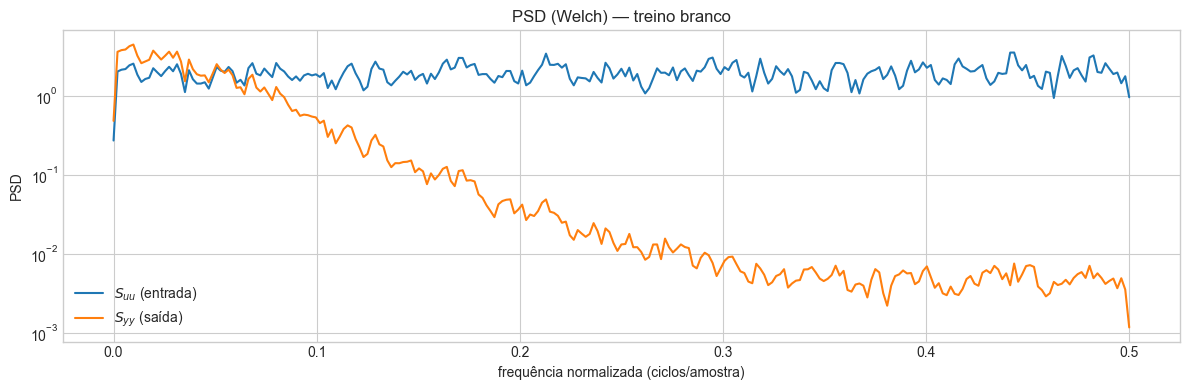

S_uu aproximadamente plana? razão max/min = 13.01


In [7]:
NPERSEG = 512
f_u, Puu = signal.welch(u_a, fs=FS, nperseg=NPERSEG)
f_y, Pyy = signal.welch(y_a, fs=FS, nperseg=NPERSEG)

plt.figure(figsize=(12, 4))
plt.semilogy(f_u, Puu, label=r"$S_{uu}$ (entrada)")
plt.semilogy(f_y, Pyy, label=r"$S_{yy}$ (saída)", color="C1")
plt.title("PSD (Welch) — treino branco")
plt.xlabel("frequência normalizada (ciclos/amostra)")
plt.ylabel("PSD")
plt.legend()
plt.tight_layout()
plt.show()

print(f"S_uu aproximadamente plana? razão max/min = {Puu.max() / Puu.min():.2f}")

**Leitura esperada:** `S_uu` aproximadamente plana (entrada branca). `S_yy` deve revelar o ganho do sistema em função da frequência (regiões de passagem e atenuação).

## A.4 — Espectro cruzado entre u[n] e y[n]

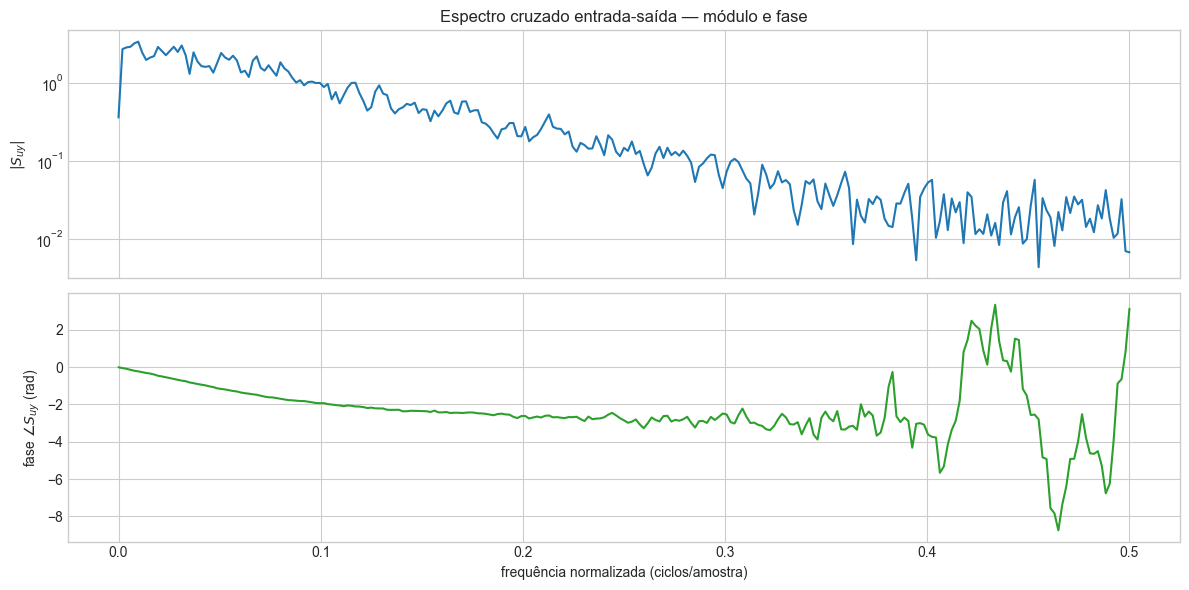

In [8]:
f_c, Suy = signal.csd(u_a, y_a, fs=FS, nperseg=NPERSEG)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].semilogy(f_c, np.abs(Suy))
axes[0].set_ylabel(r"$|S_{uy}|$")
axes[0].set_title("Espectro cruzado entrada-saída — módulo e fase")
axes[1].plot(f_c, np.unwrap(np.angle(Suy)), color="C2")
axes[1].set_ylabel(r"fase $\angle S_{uy}$ (rad)")
axes[1].set_xlabel("frequência normalizada (ciclos/amostra)")
plt.tight_layout()
plt.show()

## A.5 — Coerência entrada-saída

$$\gamma_{uy}^2(e^{j\omega}) = \frac{|S_{uy}(e^{j\omega})|^2}{S_{uu}(e^{j\omega})\, S_{yy}(e^{j\omega})}$$

Valores próximos de 1 indicam relação linear confiável naquela frequência.

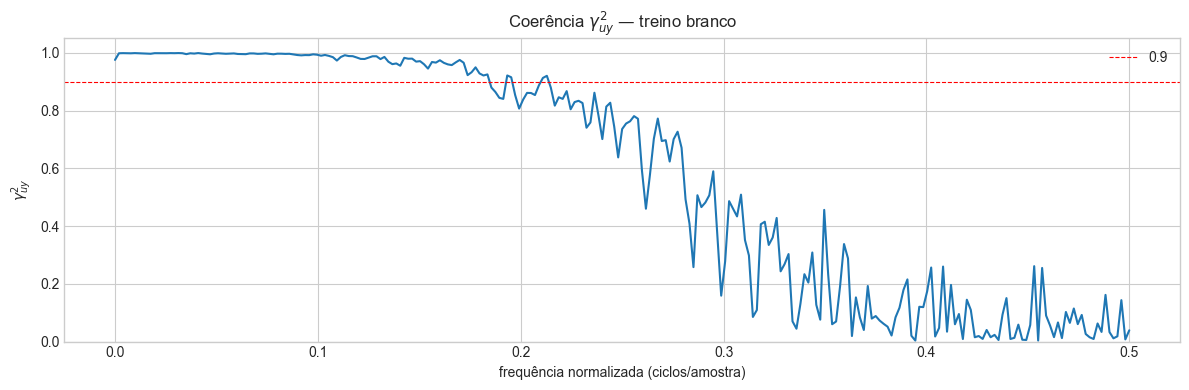

Coerência média: 0.584
Fração de frequências com coerência > 0.9: 0.385


In [9]:
f_coh, coh = signal.coherence(u_a, y_a, fs=FS, nperseg=NPERSEG)

plt.figure(figsize=(12, 4))
plt.plot(f_coh, coh)
plt.axhline(0.9, color="r", ls="--", lw=0.8, label="0.9")
plt.title(r"Coerência $\gamma_{uy}^2$ — treino branco")
plt.xlabel("frequência normalizada (ciclos/amostra)")
plt.ylabel(r"$\gamma_{uy}^2$")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Coerência média: {coh.mean():.3f}")
print(f"Fração de frequências com coerência > 0.9: {np.mean(coh > 0.9):.3f}")

## A.6 — Resposta em frequência por dois métodos

Conforme as fórmulas do material:

- **Método 1 (só módulo):** $|\hat{H}_1(e^{j\omega})| = \sqrt{\dfrac{\hat{S}_{yy}(e^{j\omega})}{\hat{S}_{uu}(e^{j\omega})}}$ — adequado quando a entrada é branca e o ruído de saída não domina.
- **Método 2 (complexo, estimador $H_1$):** $\hat{H}_2(e^{j\omega}) = \dfrac{\hat{S}_{yu}(e^{j\omega})}{\hat{S}_{uu}(e^{j\omega})}$ — fornece módulo **e** fase; deve ser lido junto com a coerência.

> **Convenção do `scipy`:** `signal.csd(u, y)` calcula $\hat{S}_{yu}$ na convenção do material (transformada de $R_{yu}[k]=E\{u[n]\,y[n+k]\}$), pois usa $\overline{U}\,Y$. Verificamos empiricamente que essa escolha produz a fase **correta** (causal), coincidente com a do FIR identificado; usar `csd(y, u)` inverteria o sinal da fase. O módulo é idêntico nos dois casos.

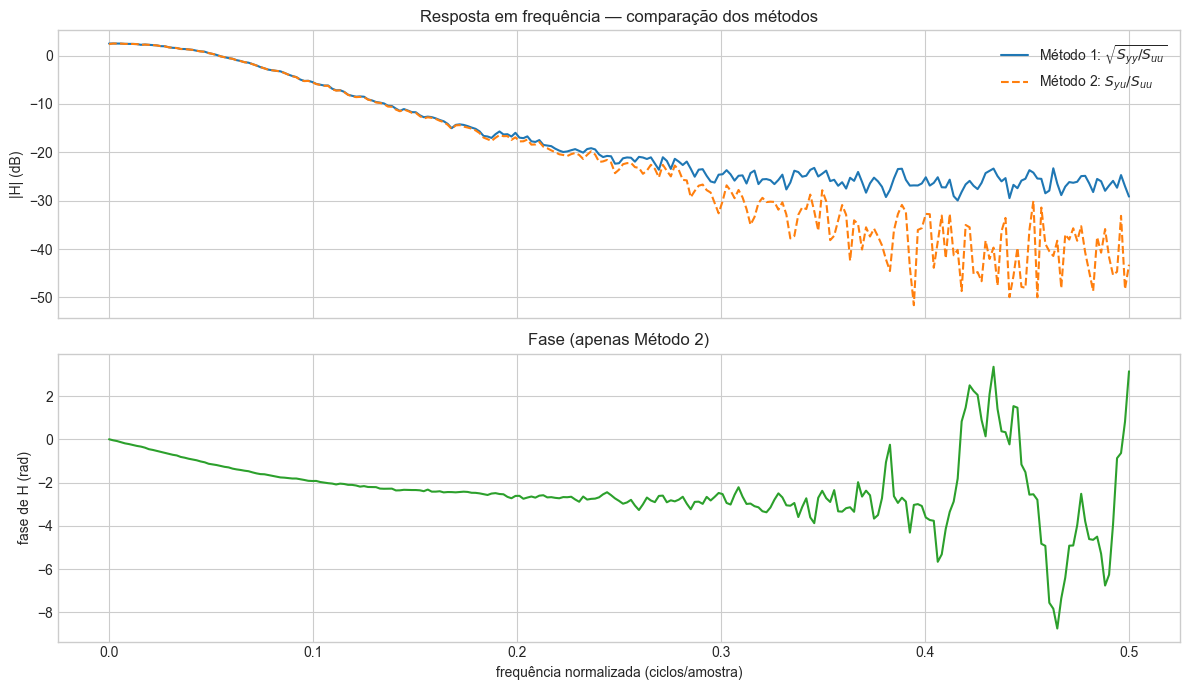

Diferença média de módulo entre métodos: 4.938 dB


In [10]:
# Método 1: |H1| = sqrt(Syy/Suu) (apenas módulo)
H_mag_method1 = np.sqrt(Pyy / Puu)
# Método 2: H2 = Syu/Suu (complexo). No scipy, csd(u, y) == S_yu do material
# (usa conj(U)*Y) e dá a fase causal correta -> Suy aqui é, de fato, S_yu.
H_method2 = Suy / Puu

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(f_u, 20 * np.log10(H_mag_method1), label=r"Método 1: $\sqrt{S_{yy}/S_{uu}}$")
axes[0].plot(f_c, 20 * np.log10(np.abs(H_method2)), label=r"Método 2: $S_{yu}/S_{uu}$", ls="--")
axes[0].set_ylabel("|H| (dB)")
axes[0].set_title("Resposta em frequência — comparação dos métodos")
axes[0].legend()
axes[1].plot(f_c, np.unwrap(np.angle(H_method2)), color="C2")
axes[1].set_ylabel("fase de H (rad)")
axes[1].set_xlabel("frequência normalizada (ciclos/amostra)")
axes[1].set_title("Fase (apenas Método 2)")
plt.tight_layout()
plt.show()

diff_db = 20 * np.log10(H_mag_method1) - 20 * np.log10(np.abs(H_method2))
print(f"Diferença média de módulo entre métodos: {np.mean(np.abs(diff_db)):.3f} dB")

## A.7 — Identificação de modelo LIT (FIR por mínimos quadrados)

Modelo $\hat{y}[n] = \sum_{k=0}^{M-1} h[k]\, u[n-k]$. Estimamos `h` por mínimos quadrados.

In [11]:
def build_fir_regressor(u, M):
    """Matriz de regressão FIR com M taps (inclui atraso 0..M-1)."""
    N = len(u)
    Phi = np.zeros((N, M))
    for k in range(M):
        Phi[k:, k] = u[: N - k]
    return Phi


def fit_eval_skip(u, y, M):
    """Ajusta FIR e avalia descartando as primeiras M-1 amostras (transitório)."""
    Phi = build_fir_regressor(u, M)
    h, *_ = np.linalg.lstsq(Phi[M - 1 :], y[M - 1 :], rcond=None)
    y_hat = Phi @ h
    e = y[M - 1 :] - y_hat[M - 1 :]
    ss_res = np.sum(e ** 2)
    ss_tot = np.sum((y[M - 1 :] - y[M - 1 :].mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    return h, y_hat, r2


# Escolha da ordem: varre M e observa R^2
orders = [5, 10, 15, 20, 30, 40, 60]
for M in orders:
    _, _, r2 = fit_eval_skip(u_a, y_a, M)
    print(f"M = {M:3d}  ->  R^2 = {r2:.5f}")

M =   5  ->  R^2 = 0.79528
M =  10  ->  R^2 = 0.98910
M =  15  ->  R^2 = 0.99016
M =  20  ->  R^2 = 0.99022
M =  30  ->  R^2 = 0.99022
M =  40  ->  R^2 = 0.99025
M =  60  ->  R^2 = 0.99033


Ordem escolhida M = 30,  R^2 (treino) = 0.99022


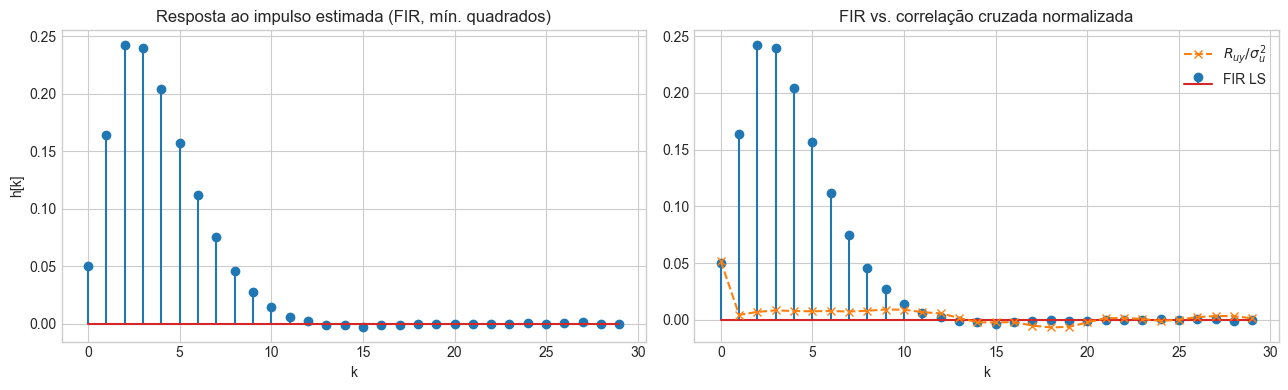

In [12]:
M = 30
h_fir, y_hat_a, r2_a = fit_eval_skip(u_a, y_a, M)
print(f"Ordem escolhida M = {M},  R^2 (treino) = {r2_a:.5f}")

# Comparação: resposta ao impulso estimada vs. R_uy/sigma_u^2 (esperado p/ entrada branca)
h_from_xcorr = r_uy[lags_cc >= 0][:M] / u_a.var()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].stem(np.arange(M), h_fir)
axes[0].set_title("Resposta ao impulso estimada (FIR, mín. quadrados)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("h[k]")
axes[1].stem(np.arange(M), h_fir, linefmt="C0-", markerfmt="C0o", label="FIR LS")
axes[1].plot(np.arange(M), h_from_xcorr, "C1x--", label=r"$R_{uy}/\sigma_u^2$")
axes[1].set_title("FIR vs. correlação cruzada normalizada")
axes[1].set_xlabel("k")
axes[1].legend()
plt.tight_layout()
plt.show()

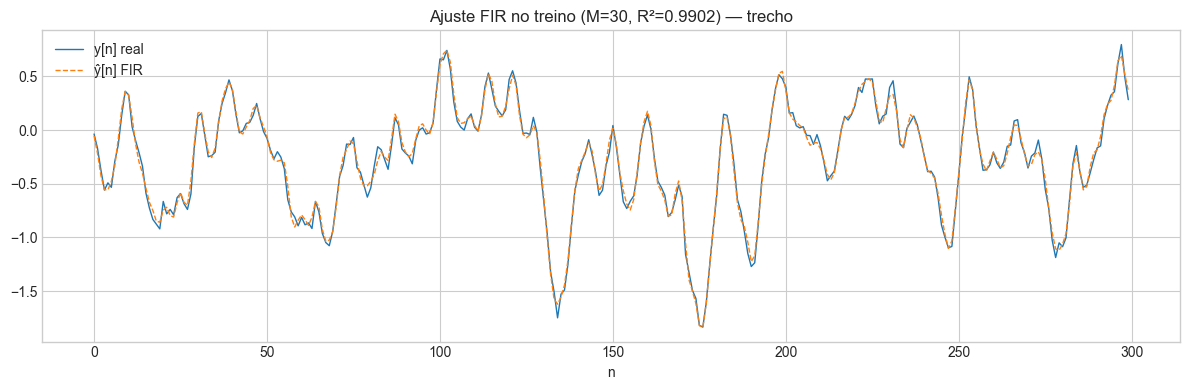

In [13]:
# Ajuste no tempo (trecho)
seg = slice(0, 300)
plt.figure(figsize=(12, 4))
plt.plot(n_a[seg], y_a[seg], label="y[n] real", lw=1.0)
plt.plot(n_a[seg], y_hat_a[seg], label="ŷ[n] FIR", lw=1.0, ls="--")
plt.title(f"Ajuste FIR no treino (M={M}, R²={r2_a:.4f}) — trecho")
plt.xlabel("n")
plt.legend()
plt.tight_layout()
plt.show()

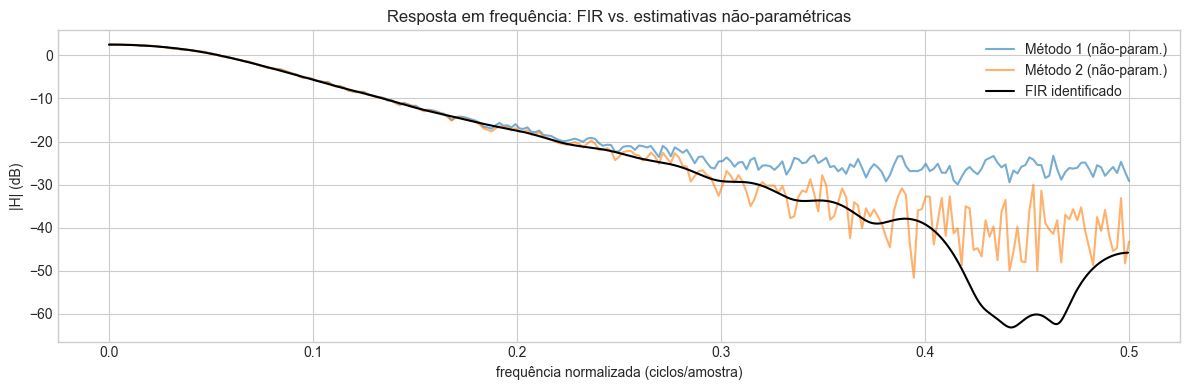

In [14]:
# Resposta em frequência do FIR identificado vs. métodos não-paramétricos
w_fir, H_fir = signal.freqz(h_fir, worN=1024, fs=FS)

plt.figure(figsize=(12, 4))
plt.plot(f_u, 20 * np.log10(H_mag_method1), label="Método 1 (não-param.)", alpha=0.6)
plt.plot(f_c, 20 * np.log10(np.abs(H_method2)), label="Método 2 (não-param.)", alpha=0.6)
plt.plot(w_fir, 20 * np.log10(np.abs(H_fir)), "k", label="FIR identificado")
plt.title("Resposta em frequência: FIR vs. estimativas não-paramétricas")
plt.xlabel("frequência normalizada (ciclos/amostra)")
plt.ylabel("|H| (dB)")
plt.legend()
plt.tight_layout()
plt.show()

## A.8 — Validação com `dados_validacao_branco.csv`

Aplicamos a entrada de validação `uval[n]` ao FIR identificado e comparamos `ŷval[n]` com `yval[n]`.

Validação -> R² = 0.99011 | RMSE = 0.04900 | FIT = 90.05%


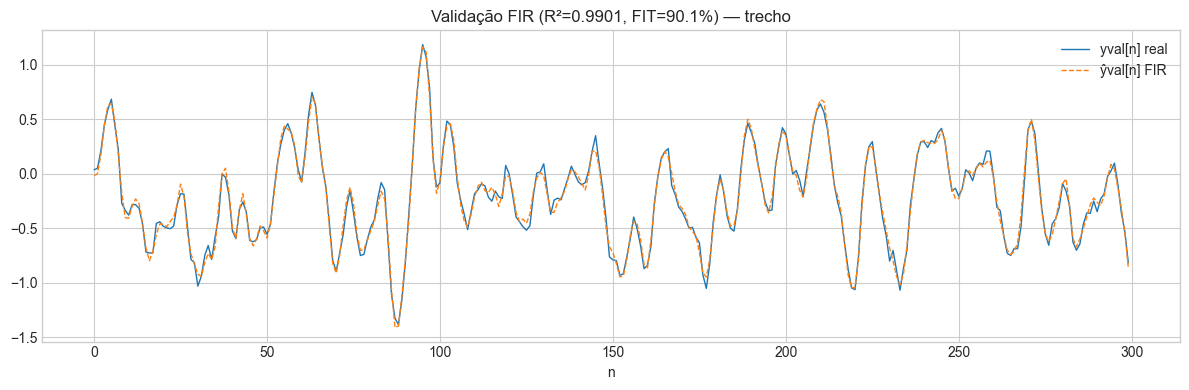

In [15]:
n_v, u_v, y_v = load_dataset("dados_validacao_branco.csv")

y_hat_v = np.convolve(u_v, h_fir)[: len(u_v)]

# Métricas (descartando transitório inicial)
skip = M
e_v = y_v[skip:] - y_hat_v[skip:]
ss_res = np.sum(e_v ** 2)
ss_tot = np.sum((y_v[skip:] - y_v[skip:].mean()) ** 2)
r2_v = 1 - ss_res / ss_tot
rmse_v = np.sqrt(np.mean(e_v ** 2))
# FIT (%) no estilo System Identification Toolbox
fit_v = 100 * (1 - np.linalg.norm(e_v) / np.linalg.norm(y_v[skip:] - y_v[skip:].mean()))

print(f"Validação -> R² = {r2_v:.5f} | RMSE = {rmse_v:.5f} | FIT = {fit_v:.2f}%")

seg = slice(0, 300)
plt.figure(figsize=(12, 4))
plt.plot(n_v[seg], y_v[seg], label="yval[n] real", lw=1.0)
plt.plot(n_v[seg], y_hat_v[seg], label="ŷval[n] FIR", lw=1.0, ls="--")
plt.title(f"Validação FIR (R²={r2_v:.4f}, FIT={fit_v:.1f}%) — trecho")
plt.xlabel("n")
plt.legend()
plt.tight_layout()
plt.show()

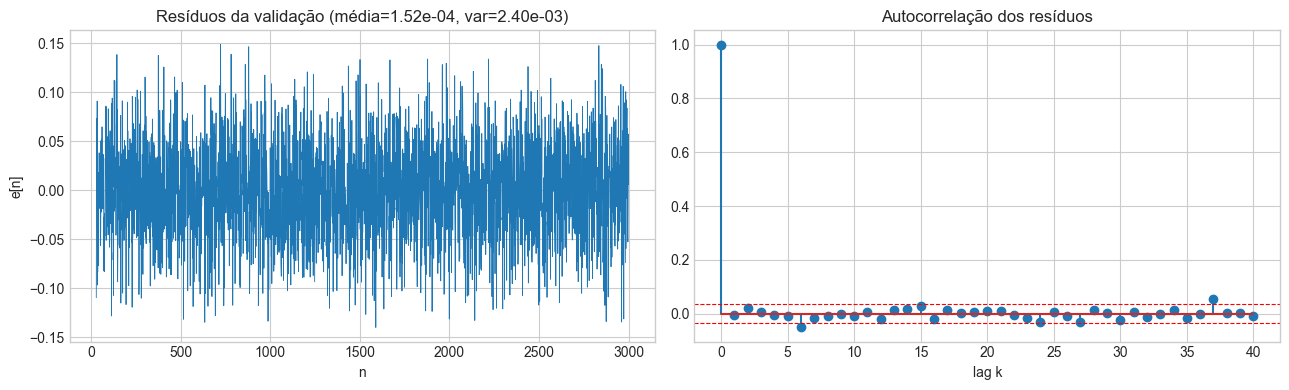

Resíduos ~ brancos e de baixa variância indicam bom modelo.


In [16]:
# Resíduos da validação
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(n_v[skip:], e_v, lw=0.6)
axes[0].set_title(f"Resíduos da validação (média={e_v.mean():.2e}, var={e_v.var():.2e})")
axes[0].set_xlabel("n")
axes[0].set_ylabel("e[n]")
r_ee = biased_autocorr(e_v, 40)
axes[1].stem(np.arange(41), r_ee / r_ee[0])
axes[1].axhline(1.96 / np.sqrt(len(e_v)), color="r", ls="--", lw=0.8)
axes[1].axhline(-1.96 / np.sqrt(len(e_v)), color="r", ls="--", lw=0.8)
axes[1].set_title("Autocorrelação dos resíduos")
axes[1].set_xlabel("lag k")
plt.tight_layout()
plt.show()

print("Resíduos ~ brancos e de baixa variância indicam bom modelo.")